## **`Task 2: Exploratory Data Analysis (EDA)`**

In [ ]:
import pandas as pd
df = pd.read_excel("ApexPlanet_DataAnalytics_Dataset_Cleaned.xlsx")
df.head()

,Order_ID,Order_Date,Customer_ID,Customer_Name,Age,Gender,City,Product,Category,Quantity,Unit_Price,Total_Sales
0,ORD100002,2025-02-25,CUST5529,Customer_227,30,Female,Bengaluru,Rice,Grocery,7,2829.77,19808.39
1,ORD100003,2025-10-14,CUST3127,Customer_182,63,Male,Bengaluru,Book,Education,5,27906.16,139530.80
2,ORD100004,2025-05-13,CUST8887,Customer_487,62,Female,Bengaluru,Book,Education,8,37491.06,299928.48
3,ORD100005,2025-12-02,CUST2515,Customer_470,65,Female,Kolkata,Mobile,Electronics,9,28541.36,256872.24
4,ORD100006,2025-11-20,CUST4796,Customer_380,44,Male,Bengaluru,Rice,Grocery,10,14036.59,140365.90


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Order_ID       1000 non-null   object        
 1   Order_Date     1000 non-null   datetime64[ns]
 2   Customer_ID    1000 non-null   object        
 3   Customer_Name  1000 non-null   object        
 4   Age            1000 non-null   int64         
 5   Gender         1000 non-null   object        
 6   City           1000 non-null   object        
 7   Product        1000 non-null   object        
 8   Category       1000 non-null   object        
 9   Quantity       1000 non-null   int64         
 10  Unit_Price     1000 non-null   float64       
 11  Total_Sales    1000 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(2), object(7)
memory usage: 93.9+ KB


In [ ]:
df.describe()

,Order_Date,Age,Quantity,Unit_Price,Total_Sales
count,1000,1000.000000,1000.000000,1000.000000,1000.000000
mean,2025-07-03 11:19:40.800000,41.353000,5.435000,25486.783410,139399.439650
min,2025-01-01 00:00:00,18.000000,1.000000,145.780000,437.340000
25%,2025-03-30 18:00:00,30.000000,3.000000,13895.722500,47066.632500
50%,2025-07-01 00:00:00,41.000000,5.000000,25398.740000,108594.025000
75%,2025-10-07 06:00:00,53.000000,8.000000,37512.382500,203722.882500
max,2026-01-01 00:00:00,65.000000,10.000000,49997.530000,493677.500000
std,NaN,13.683626,2.838632,14179.402361,114100.051546


# Univariate Analysis

Age Distribution

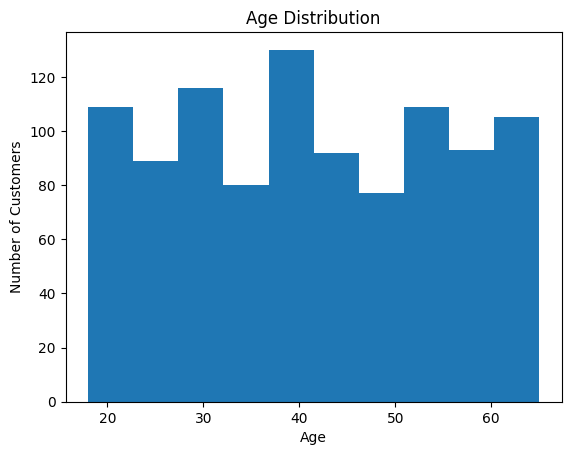

In [ ]:
import matplotlib.pyplot as plt

plt.hist(df["Age"], bins=10)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.show()

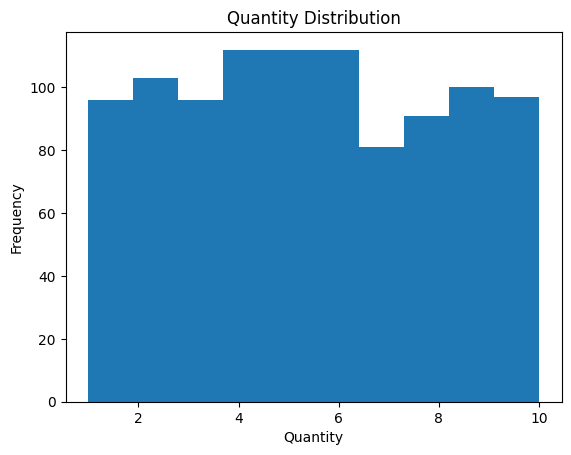

In [ ]:
plt.hist(df["Quantity"], bins=10)

plt.title("Quantity Distribution")
plt.xlabel("Quantity")
plt.ylabel("Frequency")

plt.show()

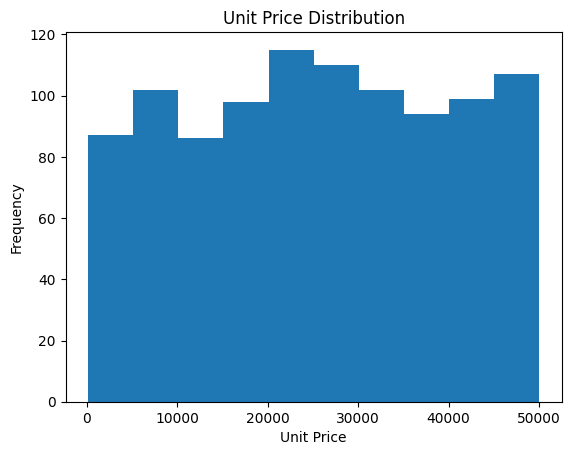

In [ ]:
plt.hist(df["Unit_Price"], bins=10)

plt.title("Unit Price Distribution")
plt.xlabel("Unit Price")
plt.ylabel("Frequency")

plt.show()

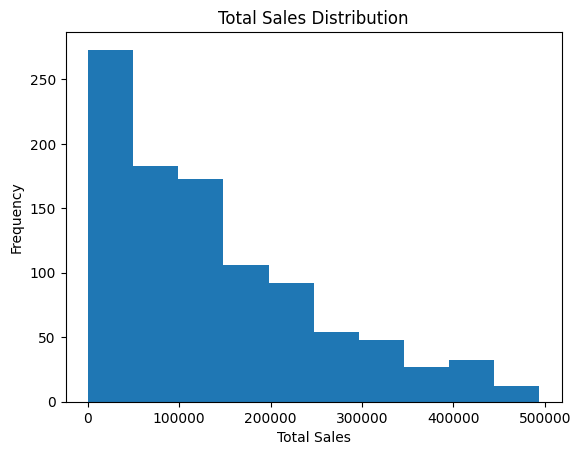

In [ ]:
plt.hist(df["Total_Sales"], bins=10)

plt.title("Total Sales Distribution")
plt.xlabel("Total Sales")
plt.ylabel("Frequency")

plt.show()

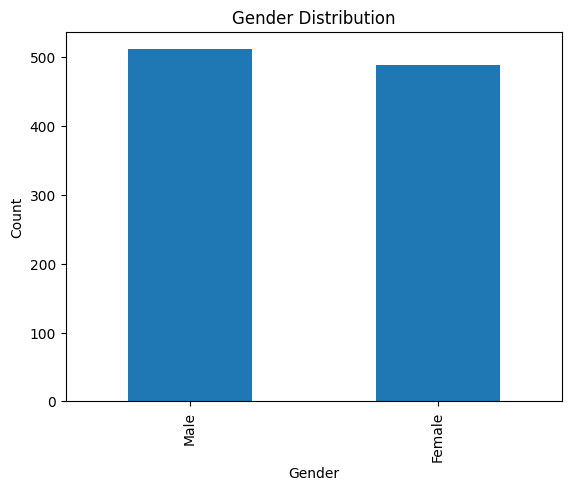

In [ ]:
df["Gender"].value_counts().plot(kind="bar")

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.show()

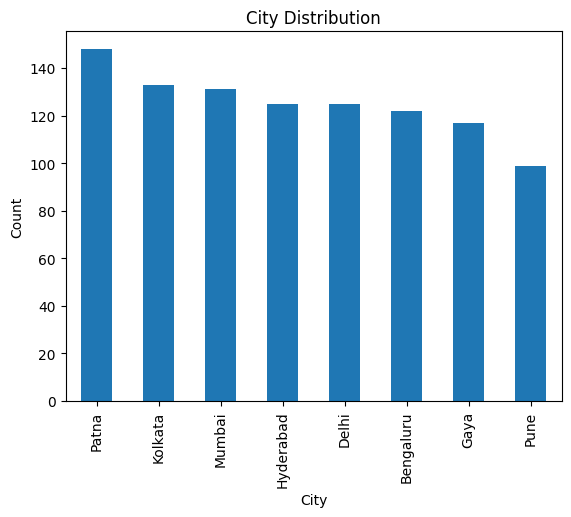

In [ ]:
df["City"].value_counts().plot(kind="bar")

plt.title("City Distribution")
plt.xlabel("City")
plt.ylabel("Count")

plt.show()

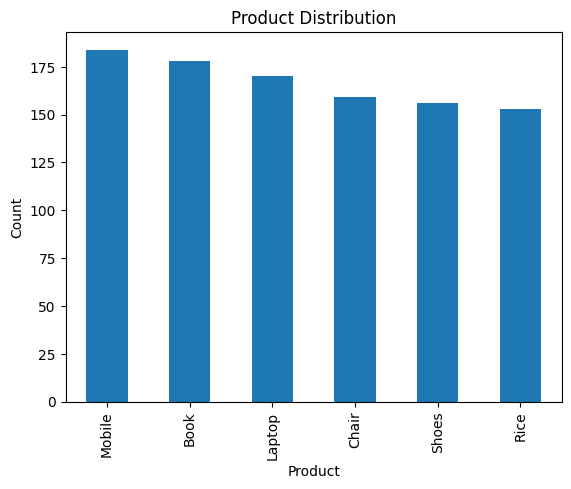

In [ ]:
df["Product"].value_counts().plot(kind="bar")

plt.title("Product Distribution")
plt.xlabel("Product")
plt.ylabel("Count")

plt.show()

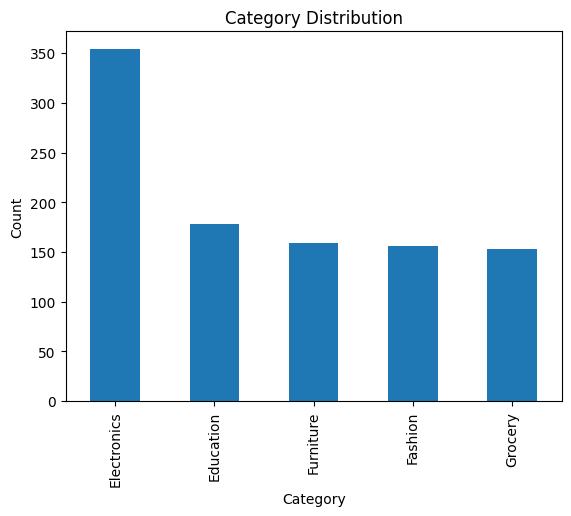

In [ ]:
df["Category"].value_counts().plot(kind="bar")

plt.title("Category Distribution")
plt.xlabel("Category")
plt.ylabel("Count")

plt.show()

# **SQL for Business Questions**

Business Question 1: Which product generated the highest total sales?

In [ ]:
df.groupby("Product")["Total_Sales"].sum().sort_values(ascending=False)

,Total_Sales
Product,
Laptop,25443008.51
Mobile,25335573.19
Book,25031689.40
Rice,22231711.28
Chair,21521561.48
Shoes,19835895.79


Business Question 2: Which city generated the highest total sales?

In [ ]:
df.groupby("City")["Total_Sales"].sum().sort_values(ascending=False)

,Total_Sales
City,
Patna,20826584.43
Kolkata,18884349.57
Bengaluru,18773574.32
Mumbai,18757050.17
Hyderabad,17166766.87
Delhi,16097079.00
Pune,14513175.90
Gaya,14380859.39


Business Question 3: Which product category generated the highest total sales?

In [ ]:
df.groupby("Category")["Total_Sales"].sum().sort_values(ascending=False)

,Total_Sales
Category,
Electronics,50778581.70
Education,25031689.40
Grocery,22231711.28
Furniture,21521561.48
Fashion,19835895.79


Business Question 4: Which gender contributed the highest total sales?

In [ ]:
df.groupby("Gender")["Total_Sales"].sum().sort_values(ascending=False)

,Total_Sales
Gender,
Male,72463550.63
Female,66935889.02


Business Question 5: Which age group generated the highest total sales?

In [ ]:
import pandas as pd

bins = [18, 26, 36, 46, 56, 66]
labels = ['18-25', '26-35', '36-45', '46-55', '56-65']
df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False, include_lowest=True)

df.groupby("Age_Group")["Total_Sales"].sum().sort_values(ascending=False)

/tmp/ipykernel_710/1178269772.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Age_Group")["Total_Sales"].sum().sort_values(ascending=False)


,Total_Sales
Age_Group,
36-45,31533245.71
26-35,29632336.96
46-55,28216508.63
56-65,27733251.41
18-25,22284096.94


# Multivariate Analysis & Correlation

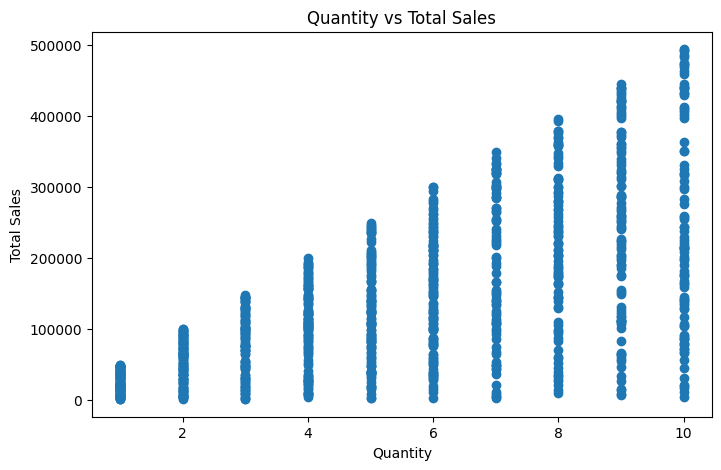

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt. scatter(df["Quantity"], df["Total_Sales"])
plt.title("Quantity vs Total Sales")
plt.xlabel("Quantity")
plt.ylabel("Total Sales")
plt.show()

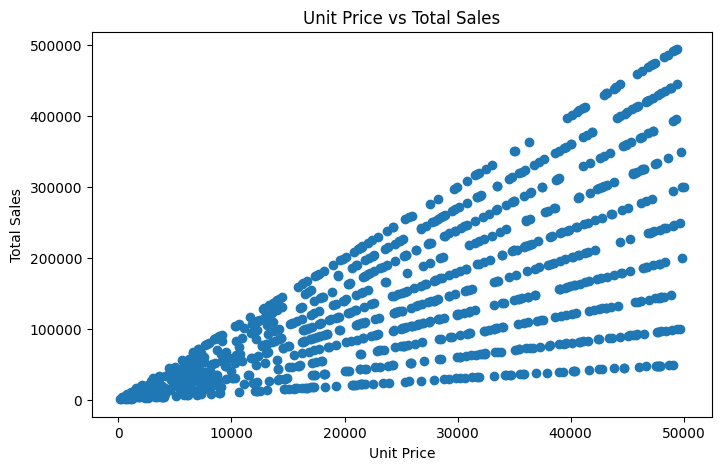

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(df["Unit_Price"], df["Total_Sales"])
plt.title("Unit Price vs Total Sales")
plt.xlabel("Unit Price")
plt.ylabel("Total Sales")
plt.show()

In [ ]:
correlation = df[["Age", "Quantity", "Unit_Price", "Total_Sales"]].corr()

correlation

,Age,Quantity,Unit_Price,Total_Sales
Age,1.000000,-0.027666,-0.011955,0.001294
Quantity,-0.027666,1.000000,0.021855,0.646641
Unit_Price,-0.011955,0.021855,1.000000,0.686303
Total_Sales,0.001294,0.646641,0.686303,1.000000


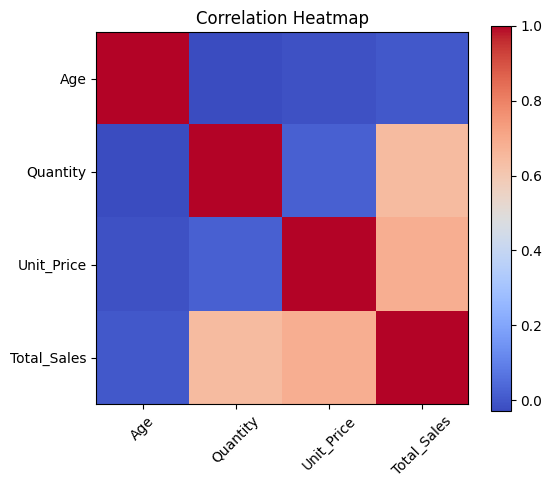

In [ ]:
import matplotlib.pyplot as plt

correlation = df[["Age", "Quantity", "Unit_Price", "Total_Sales"]].corr()

plt.figure(figsize=(6,5))
plt.imshow(correlation, cmap="coolwarm", interpolation="nearest")

plt.colorbar()

plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=45)
plt.yticks(range(len(correlation.columns)), correlation.columns)

plt.title("Correlation Heatmap")

plt.show()

In [ ]:
total_sales = df["Total_Sales"].sum()
total_orders = len(df)
total_customers = df["Customer_ID"].nunique()

top_product = df.groupby("Product")["Total_Sales"].sum().idxmax()
top_city = df.groupby("City")["Total_Sales"].sum().idxmax()

print("Total Sales :", total_sales)
print("Total Orders :", total_orders)
print("Total Customers :", total_customers)
print("Top Product :", top_product)
print("Top City :", top_city)

Total Sales : 139399439.65
Total Orders : 1000
Total Customers : 947
Top Product : Laptop
Top City : Patna


In [ ]:
total_sales = df["Total_Sales"].sum()
total_orders = df["Order_ID"].nunique()
total_customers = df["Customer_ID"].nunique()

top_product = df.groupby("Product")["Total_Sales"].sum().idxmax()
top_city = df.groupby("City")["Total_Sales"].sum().idxmax()

print("Total Sales      : ₹{:,.2f}".format(total_sales))
print("Total Orders     :", total_orders)
print("Total Customers  :", total_customers)
print("Top Product      :", top_product)
print("Top City         :", top_city)

Total Sales      : ₹139,399,439.65
Total Orders     : 992
Total Customers  : 947
Top Product      : Laptop
Top City         : Patna


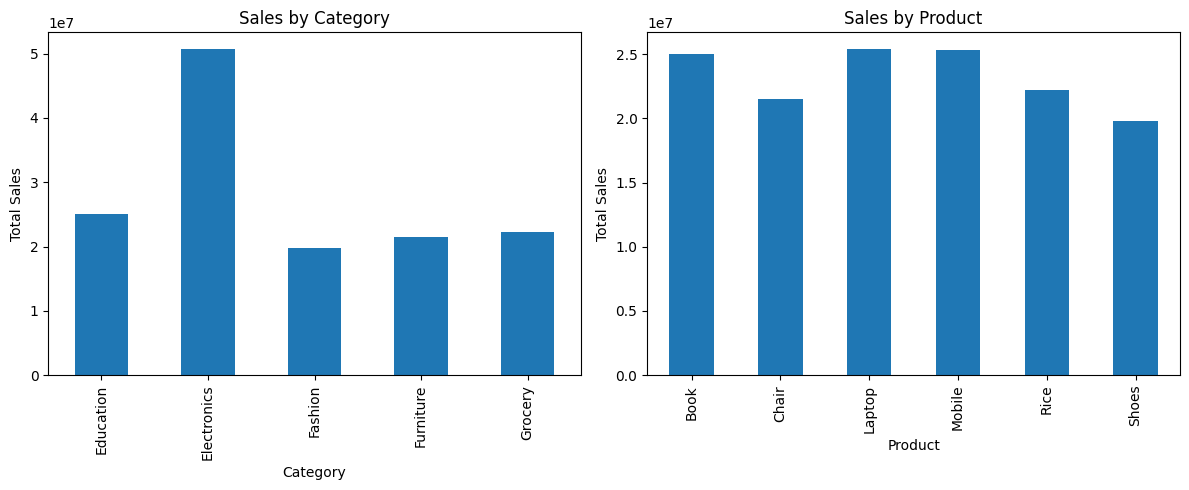

In [ ]:
import matplotlib.pyplot as plt

# Data for charts
category_sales = df.groupby("Category")["Total_Sales"].sum()
product_sales = df.groupby("Product")["Total_Sales"].sum()

plt.figure(figsize=(12,5))

# Chart 1
plt.subplot(1,2,1)
category_sales.plot(kind="bar")
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")

# Chart 2
plt.subplot(1,2,2)
product_sales.plot(kind="bar")
plt.title("Sales by Product")
plt.xlabel("Product")
plt.ylabel("Total Sales")

plt.tight_layout()
plt.show()